In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [4]:
state_by_month_cps = pd.read_csv('/Users/chrisgee/UCSD2526/replication_project/data/state_by_month_cps.csv')
state_by_month_cps['PERIOD'] = pd.to_datetime(state_by_month_cps['PERIOD']).dt.to_period('M')
state_by_month_cps

,Unnamed: 0,PERIOD,IND1990,EMPSTAT,ASECWT,WTFINL,DID_DUMMY,NJ_PA,POLICY_PERIOD,RECESSION_PERIOD
0,1,1988-01,192,1,NaN,1537.2900,0,1,0,1
1,2,1988-01,910,1,NaN,1266.4100,0,1,0,1
2,6,1988-01,712,1,NaN,1184.5300,0,1,0,1
3,10,1988-01,771,1,NaN,1254.0600,0,1,0,1
4,11,1988-01,601,1,NaN,1340.4600,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
758732,1519207,1997-12,831,1,NaN,2051.2907,0,0,1,0
758733,1519209,1997-12,850,1,NaN,2327.8280,0,0,1,0
758734,1519213,1997-12,831,1,NaN,2039.9635,0,0,1,0
758735,1519214,1997-12,60,1,NaN,2142.6876,0,0,1,0


In [5]:
# Filtering for CPS data points by removing all ASEC surveys
# Querying CPS data for surveys of people working at "eating and drinking places" under the IND1990 CPS variable breakdown
state_by_month_cps = state_by_month_cps[(state_by_month_cps['ASECWT'].isna() == True) & (state_by_month_cps['IND1990'] == 641)].reset_index()

# Aggregating to group weights of individuals for each period that met filtering criteria
state_by_month_cps = state_by_month_cps.groupby(['NJ_PA', 'PERIOD', 'EMPSTAT'])['WTFINL'].sum().reset_index()
state_by_month_cps

,NJ_PA,PERIOD,EMPSTAT,WTFINL
0,0,1988-01,0,25662.1400
1,0,1988-01,1,233245.2700
2,0,1988-02,0,16490.7400
3,0,1988-02,1,206743.6300
4,0,1988-03,0,27165.7900
...,...,...,...,...
475,1,1997-10,1,179518.6538
476,1,1997-11,0,7015.4418
477,1,1997-11,1,164377.2749
478,1,1997-12,0,18255.0463


In [6]:
# Pivoting table to properly find the state by month average employment for each state
state_by_month_cps_pivot = state_by_month_cps.pivot(
    index=['PERIOD', 'NJ_PA'],
    columns='EMPSTAT',
    values='WTFINL'
).reset_index().sort_values(by=['NJ_PA', 'PERIOD'])

state_by_month_cps_pivot['WTFINL'] = state_by_month_cps_pivot[1] / (state_by_month_cps_pivot[1] + state_by_month_cps_pivot[0])
state_by_month_cps_pivot

EMPSTAT,PERIOD,NJ_PA,0,1,WTFINL
0,1988-01,0,25662.1400,233245.2700,0.900883
2,1988-02,0,16490.7400,206743.6300,0.926128
4,1988-03,0,27165.7900,218862.5700,0.889583
6,1988-04,0,18777.4300,243557.3800,0.928422
8,1988-05,0,36741.3500,292737.9400,0.888487
...,...,...,...,...,...
231,1997-08,1,12953.8796,195959.2994,0.937994
233,1997-09,1,19364.1432,170358.7339,0.897935
235,1997-10,1,11525.3345,179518.6538,0.939672
237,1997-11,1,7015.4418,164377.2749,0.959068


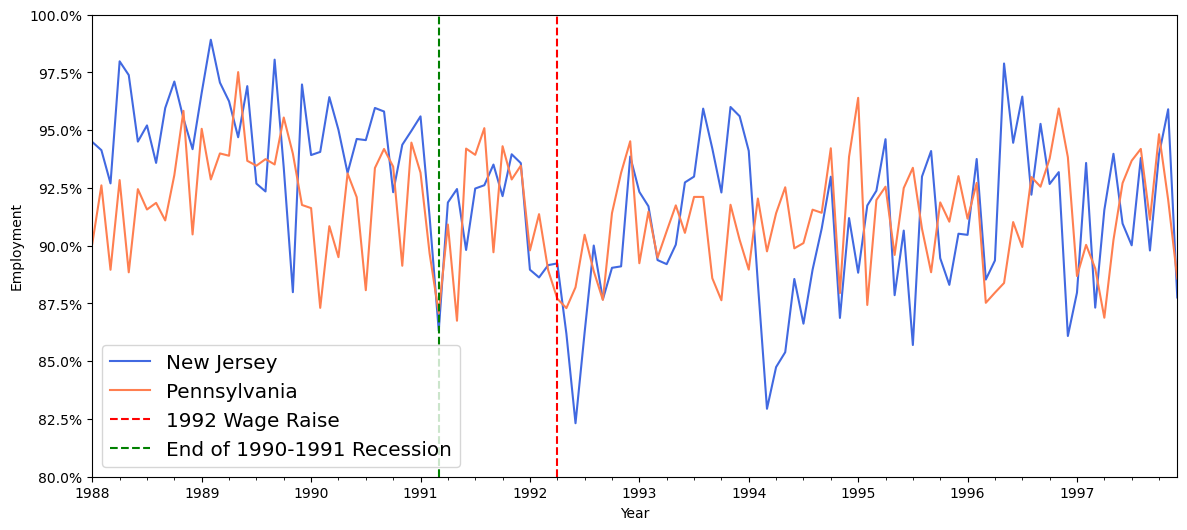

In [7]:
# Creating graph for employment percentage at a state x monthly period for New Jersey and Pennsylvania
fig, ax = plt.subplots(figsize=(14, 6))

nj_state_by_month_cps = state_by_month_cps_pivot[state_by_month_cps_pivot.get('NJ_PA') == 1].set_index('PERIOD')
pa_state_by_month_cps = state_by_month_cps_pivot[state_by_month_cps_pivot.get('NJ_PA') == 0].set_index('PERIOD')

nj_state_by_month_cps.plot(kind='line', y='WTFINL', ax=ax, label = 'New Jersey', color ='royalblue');
pa_state_by_month_cps.plot(kind='line', y='WTFINL', ax=ax, label='Pennsylvania', color='coral');

policy_period = pd.Period('1992-04', freq = 'M');
recession_period = pd.Period('1991-03', freq = 'M');
ax.axvline(x=policy_period, color='red', linestyle='--', label='1992 Wage Raise');
ax.axvline(x=recession_period, color = 'green', linestyle='--', label='End of 1990-1991 Recession');
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.xlabel('Year')
plt.ylabel('Employment')
plt.ylim(0.8, 1)
plt.legend(fontsize='x-large')
fig.savefig('/Users/chrisgee/UCSD2526/replication_project/output/CPS_641_EMPLOYMENT_1988_1998', dpi=300, bbox_inches='tight')